In [2]:
%load_ext autoreload
%autoreload 2

In [3]:


from Nozzle_2D_checkpoint4_2 import Nozzle
import matplotlib.pyplot as plt
import numpy as np
import pickle



In [5]:
SUPERCOARSE = Nozzle("inputs/RAMP_inputs.nml")
SUPERCOARSE.CFL = .1


self = SUPERCOARSE 
self.CFL = .0000001
self.iter_max = 78000

# RUN MEDIUM SIMULATION
self.set_arrays()
#self.set_curved_geometry()s
self.load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL2/Meshes/Inlet.417x129.grd")
self.set_normals()
self.compute_all_areas()
self.is_foil = False


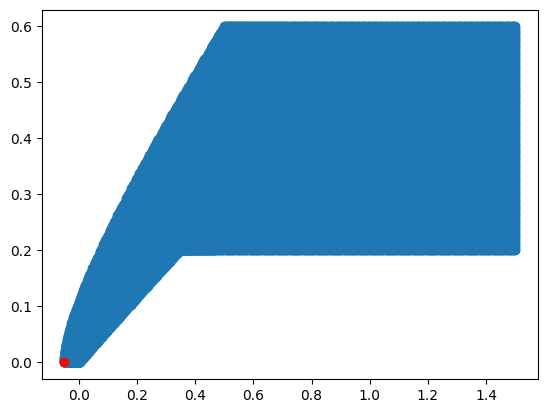

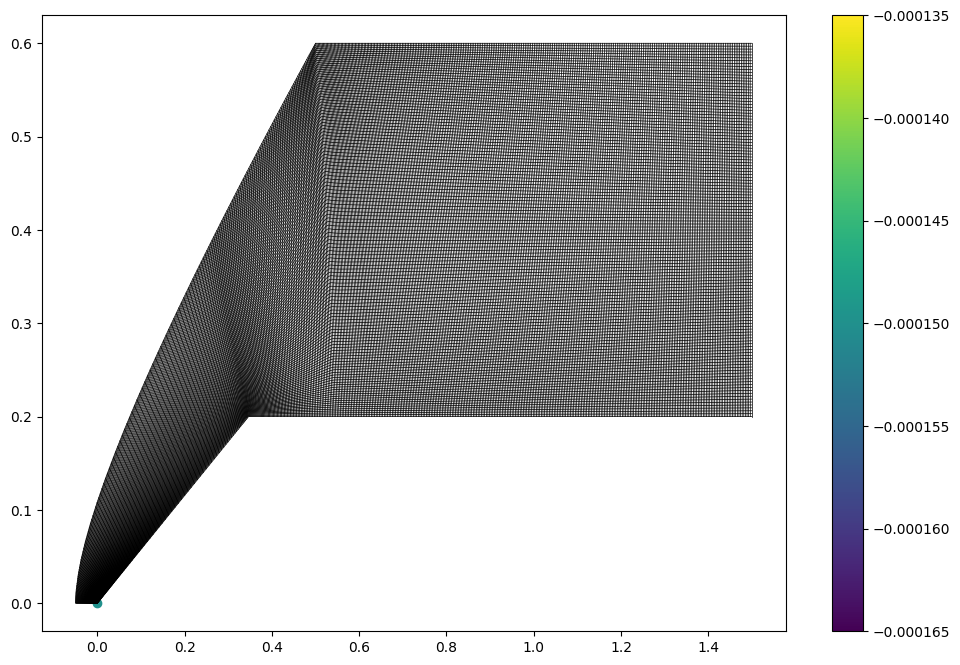

In [6]:


xx = self.x
yy =self.y
fig, ax = plt.subplots(figsize=(12,8))
for j in range(xx.shape[1]):
    ax.plot(xx[:, j], yy[:, j], 'k-', linewidth=0.5)

# Plot horizontal lines (loop over rows)
for i in range(xx.shape[0]):
    ax.plot(xx[i, :], yy[i, :], 'k-', linewidth=0.5)
index = 0
x11_index = 2
x22_index = 1
x12_index = 3
x21_index = 0
plt.scatter(x_cells[x21_index,index],y_cells[x21_index,index],c=x_cells[x21_index,index])

plt.colorbar()

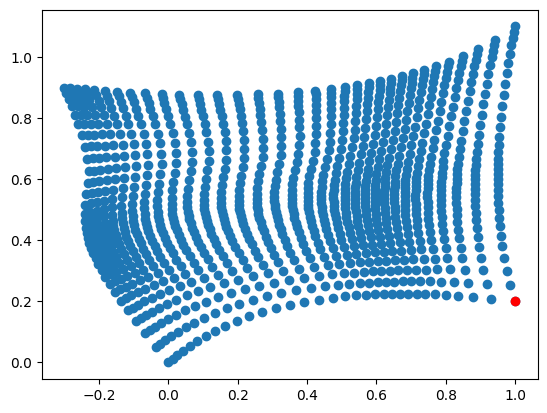

In [ ]:
x = self.x
y = self.y
plt.scatter(x[::-1],y[::-1])
plt.plot((x[::-1])[0,0],(y[::-1])[0,0],"o",color = "red")


x_temp = x
y_temp = y

x11 = x[0:-1,0:-1]
x12 = x[0:-1,1:]
x21 = x[1:,0:-1]
x22 = x[1:,1:]

y11 = y[0:-1,0:-1]
y12 = y[0:-1,1:]
y21 = y[1:,0:-1]
y22 = y[1:,1:]

In [ ]:
self.x.shape

(33, 33)

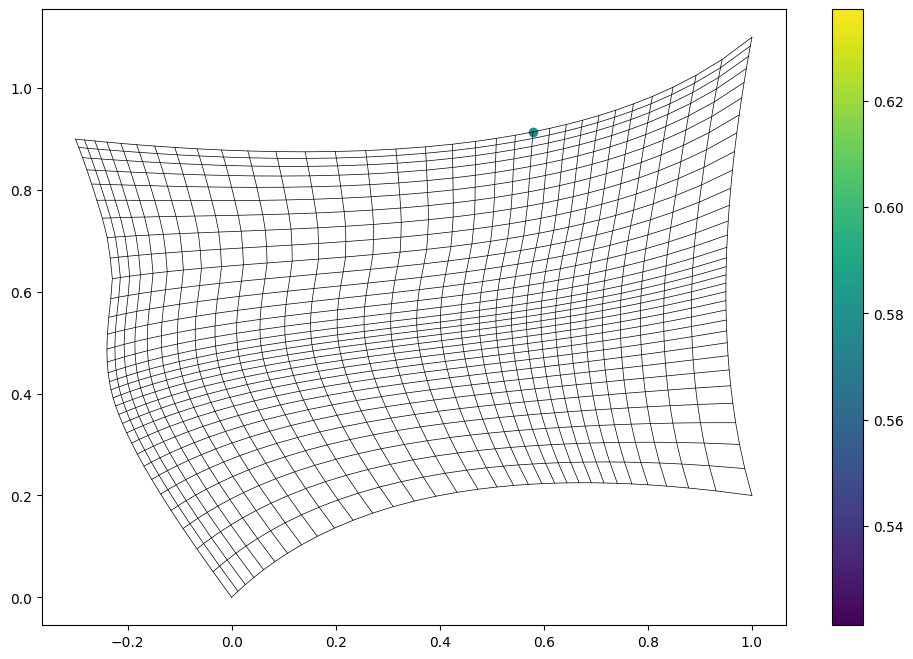

In [ ]:
x_cells= np.array([x12,x11,x22,x21])
y_cells = np.array([y12,y11,y22,y21])
x_cells = x_cells.reshape((4,x11.shape[0]*x11.shape[1]))
y_cells = y_cells.reshape((4,x11.shape[0]*x11.shape[1]))

np.savetxt("Curvilinear_xx.csv",(x_cells.T).copy(),delimiter=",")
np.savetxt("Curvilinear_yy.csv",(y_cells.T).copy(),delimiter=",")

xx = self.x
yy =self.y
fig, ax = plt.subplots(figsize=(12,8))
for j in range(xx.shape[1]):
    ax.plot(xx[:, j], yy[:, j], 'k-', linewidth=0.5)

# Plot horizontal lines (loop over rows)
for i in range(xx.shape[0]):
    ax.plot(xx[i, :], yy[i, :], 'k-', linewidth=0.5)
index = 10
x11_index = 0
x22_index = 3
x12_index = 1
x21_index = 2
plt.scatter(x_cells[x11_index,index],y_cells[x11_index,index],c=x_cells[x11_index,index])

plt.colorbar()

In [ ]:
#self.set_initial_conditions2(direction="down")
self.set_initial_foil_conditions(boundary_mach=.1)
#self.set_foil_inflow(boundary_mach=.1)


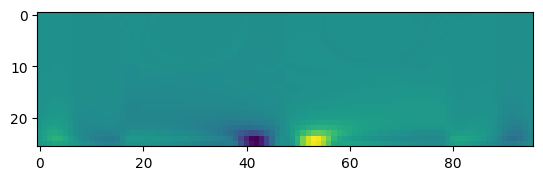

In [ ]:
plt.imshow(self.compute_residual_cell()[2])

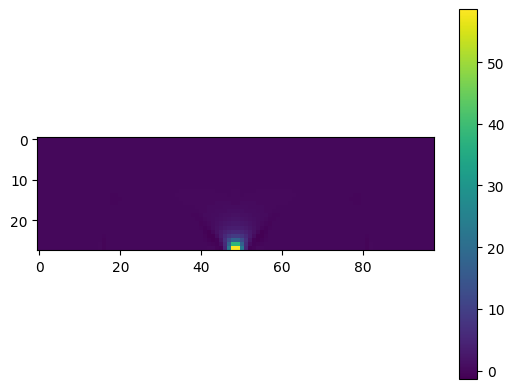

In [ ]:
#self.set_inflow_conditions(direction="down",boundary_mach=.075)
R0 = np.linalg.norm(self.iteration_step()[0])
plt.imshow(self.V[1,::-1])
plt.colorbar()

In [ ]:
#self.set_foil_inflow(boundary_mach=.1)
R0 = np.linalg.norm(self.iteration_step()[0])
self.set_normal_bcs_FOIL()

Iteration0   5281.682881966221


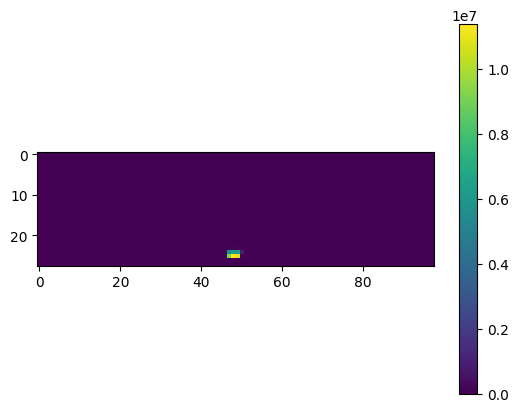

In [ ]:
self.CFL = .001
for i in range(1):

    #self.set_inflow_conditions(direction="down")
    self.set_foil_inflow(boundary_mach=.85)
    R1 = self.iteration_step()
    self.V[:,:,0] = self.V[:,:,1]
    self.V[:,:,-1] = self.V[:,:,-2]
    self.set_normal_bcs_FOIL()
    #self.set_normal_bcs()
    print(f"Iteration{i}  ",np.linalg.norm(R1[0])/(R0))
plt.imshow(self.V[1,::-1])
plt.colorbar()


In [ ]:
#np.save("checkpoint_V001",self.V)
#np.save("checkpoint_U001",self.U)

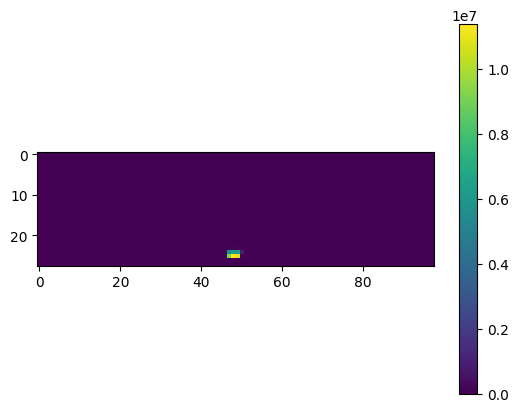

In [ ]:

plt.imshow(self.V[1,::-1])
plt.colorbar()

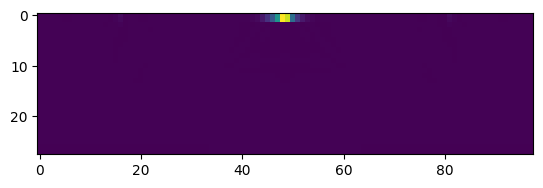

In [ ]:
plt.imshow(self.V[0])

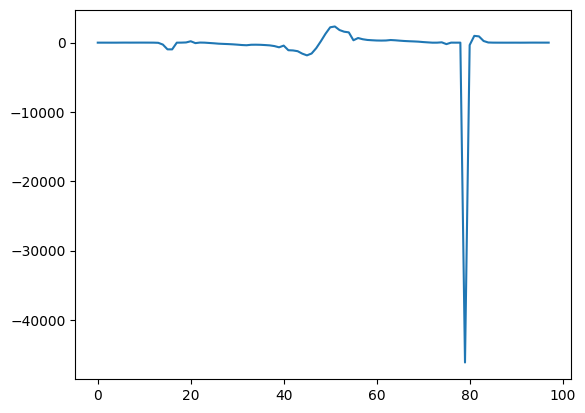

In [ ]:
plt.plot(self.V[2,0,:])

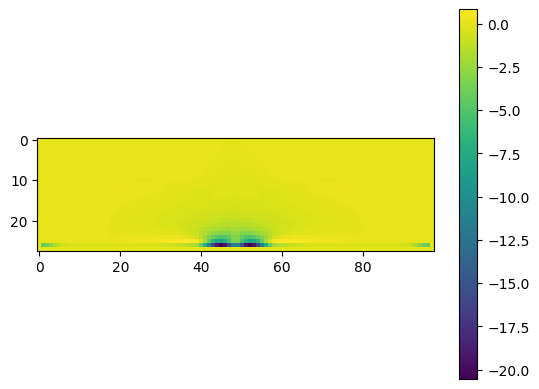

In [ ]:
plt.imshow(R1[1])
plt.colorbar()

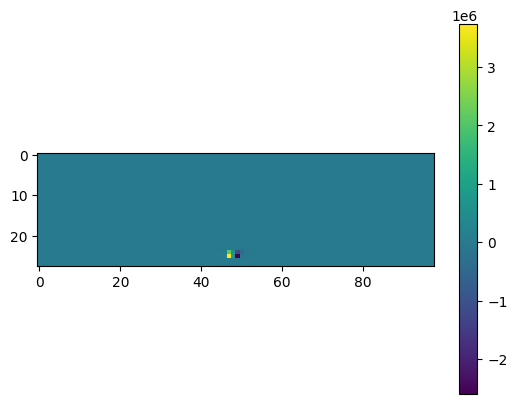

In [ ]:

plt.imshow(self.V[2,::-1])
plt.colorbar()

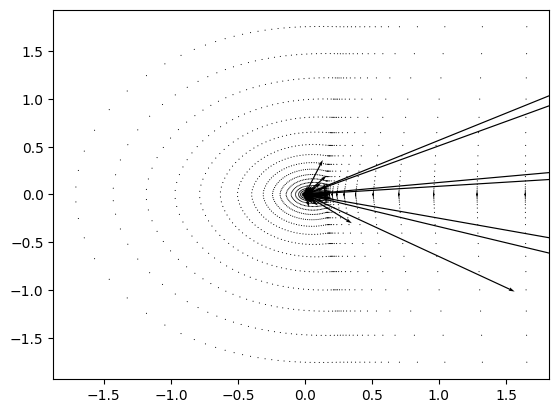

In [ ]:
self.plot_primitive("velocity")



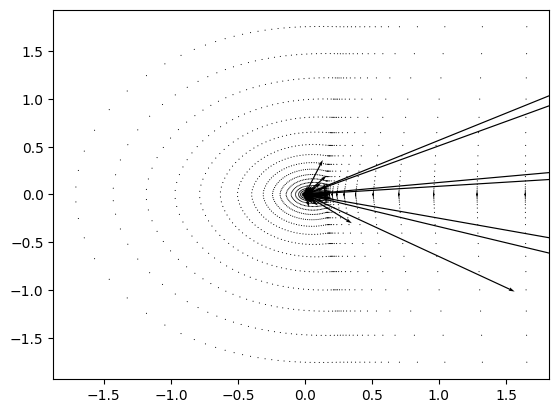

In [ ]:
midpoint_tempx = (self.x[1:,:]+self.x[0:-1,:])/2
midpointxx = (midpoint_tempx[:,1:]+midpoint_tempx[:,0:-1])/2
midpoint_tempy = (self.y[1:,:]+self.y[0:-1,:])/2
midpointyy = (midpoint_tempy[:,1:]+midpoint_tempy[:,0:-1])/2


plt.quiver(midpointxx,midpointyy,self.V[self.u_idx,1:-1,1:-1],self.V[self.v_idx,1:-1,1:-1])

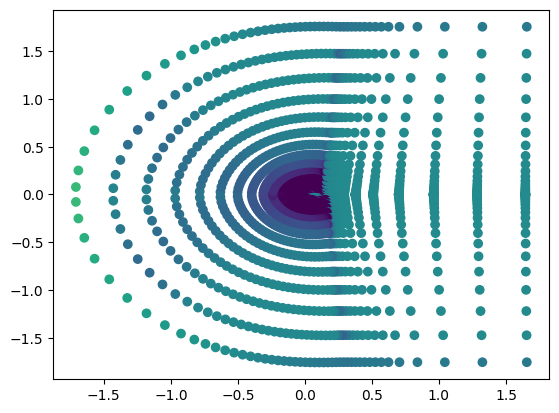

In [ ]:
plt.scatter(midpointxx.flatten(),midpointyy.flatten(),c=(self.V[self.p_idx,1:-1,1:-1]).flatten())

In [ ]:
self.V[self.p_idx,1:-1,1:-1]

array([[65.31563466, 65.2967568 , 65.179291  , ..., 65.17931908,
        65.29676606, 65.31563697],
       [65.3579488 , 65.34978247, 65.2838962 , ..., 65.28391269,
        65.34978745, 65.35794947],
       [65.38583511, 65.38191139, 65.35562198, ..., 65.35563018,
        65.38191337, 65.38583517],
       ...,
       [65.38734445, 65.36445069, 65.29556597, ..., 65.2955908 ,
        65.36445903, 65.38734759],
       [65.38763919, 65.36576911, 65.27763848, ..., 65.2776767 ,
        65.36577855, 65.38764224],
       [55.60527851, 55.60645031, 55.59344037, ..., 55.59349929,
        55.60646969, 55.60528548]])

In [ ]:
import pyvista as pv

xx = midpointxx
grid = pv.StructuredGrid(midpointxx,midpointyy, np.zeros_like(self.V[self.p_idx,1:-1,1:-1]))

grid["pressure"] = self.V[self.p_idx,1:-1,1:-1].T.flatten()
Ux = self.V[self.u_idx,1:-1,1:-1].T
Uy = self.V[self.v_idx,1:-1,1:-1].T
vel = np.stack([Ux, Uy, np.zeros_like(Ux)], axis=-1).reshape(-1, 3)
grid["velocity"] = vel
grid.save("output.vtk")  # or .vtu

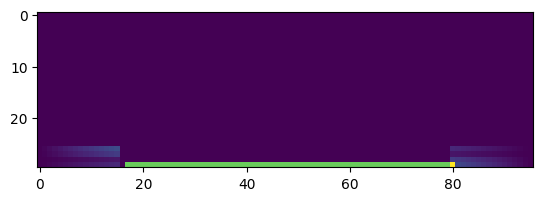

In [ ]:
F_temp = np.sin(2+np.zeros((self.V.shape[1]+2, self.V.shape[2]-2)))
num_vals = 16

(F_temp[2,self.NJ-num_vals-1:])[::-1] = np.array([i for i in range(16)])
(F_temp[3,self.NJ-num_vals-1:])[::-1] = np.array([2*i for i in range(16)])
F_temp[2,0:num_vals] = np.array([3*i for i in range(16)])
F_temp[3,0:num_vals] = np.array([4*i for i in range(16)])


F_temp[0,0:num_vals] = (F_temp[3,self.NJ-num_vals-1:])[::-1]
F_temp[1,0:num_vals] = (F_temp[2,self.NJ-num_vals-1:])[::-1]

(F_temp[0,self.NJ-num_vals-1:]) = F_temp[3,0:num_vals][::-1]
(F_temp[1,self.NJ-num_vals-1:]) = F_temp[2,0:num_vals][::-1]

top,bottom = self.get_boundary_conditions_NORMALS()
F_temp[0,num_vals+1:self.NJ-num_vals] = 200+(F_temp[0,num_vals+1:self.NJ-num_vals])


plt.imshow(F_temp[::-1])